In [1]:
import numpy as np
import nengo
import sys

import logging
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG, format="[%(name)s/%(levelname)s]: %(message)s")

import nengo_aie

[aie._mlir_libs/DEBUG]: Initializing MLIR with module: _mlirRegisterEverything
[aie._mlir_libs/DEBUG]: Registering dialects from initializer <module 'aie._mlir_libs._mlirRegisterEverything' from '/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/mlir_aie/python/aie/_mlir_libs/_mlirRegisterEverything.cpython-312-x86_64-linux-gnu.so'>
[einspect.protocols.delayed_bind/DEBUG]: [Py.IncRef()] Type hints: {'obj': <class 'object'>, 'return': <class 'NoneType'>}
[einspect.protocols.delayed_bind/DEBUG]: [Py.IncRef()] Set func: ('py_object') -> 'None'
[einspect.protocols.delayed_bind/DEBUG]: [Py.DecRef()] Type hints: {'obj': <class 'object'>, 'return': <class 'NoneType'>}
[einspect.protocols.delayed_bind/DEBUG]: [Py.DecRef()] Set func: ('py_object') -> 'None'
[einspect.structs.deco/DEBUG]: Annotated: typing.Annotated[int, <class 'ctypes.c_ulong'>] -> ('_gc_next', <class 'ctypes.c_ulong'>)
[einspect.structs.deco/DEBUG]: Annotated: typing.Annotated[int, <class 'ctypes.c_ulong'>] -> ('_gc_

In [2]:
model = nengo.Network()

with model:
    A = nengo.Ensemble(100, dimensions=1)
    A_squared = nengo.Ensemble(100, dimensions=1)
    error = nengo.Ensemble(100, dimensions=1)

    conn = nengo_aie.AIEConnection(A, A_squared)

    conn.learning_rule_type = nengo.PES(learning_rate=3e-4)

    nengo_aie.AIEConnection(error, conn.learning_rule)

    nengo_aie.AIEConnection(A_squared, error)

    nengo_aie.AIEConnection(A, error, function=lambda x: x**2, transform=-1)

In [3]:
with model:
    input_node = nengo.Node(output=lambda t: int(6 * t / 5) / 3.0 % 2 - 1)

    nengo_aie.AIEConnection(input_node, A)

    stop_learning = nengo.Node(output=lambda t: t >= 15)

    nengo_aie.AIEConnection(stop_learning, error.neurons, transform = -20 * np.ones((error.n_neurons, 1)))

In [4]:
with model:
    input_node_probe = nengo.Probe(input_node)
    A_probe = nengo.Probe(A, synapse=0.01)
    A_squared_probe = nengo.Probe(A_squared, synapse=0.01)
    error_probe = nengo.Probe(error, synapse=0.01)
    learn_probe = nengo.Probe(stop_learning, synapse=None)

In [7]:
with nengo_aie.AIESimulator(model) as sim:
    sim.run(20)

[nengo_aie.simulator/INFO]: Initializing simulator
[nengo_aie.builder/INFO]: Initialied builder
[nengo_aie.builder/DEBUG]: Using default builder for Network
[nengo.builder.network/DEBUG]: Network step 1: Building ensembles and nodes
[nengo_aie.builder/DEBUG]: Using default builder for Ensemble
[nengo_aie.builder/DEBUG]: Using default builder for LIF
[nengo_aie.builder/DEBUG]: Using default builder for Ensemble
[nengo_aie.builder/DEBUG]: Using default builder for LIF
[nengo_aie.builder/DEBUG]: Using default builder for Ensemble
[nengo_aie.builder/DEBUG]: Using default builder for LIF
[nengo_aie.builder/DEBUG]: Using default builder for Node
[nengo_aie.builder/DEBUG]: Using default builder for Node
[nengo.builder.network/DEBUG]: Network step 2: Building subnetworks
[nengo.builder.network/DEBUG]: Network step 3: Building connections
[nengo_aie.builder/DEBUG]: Using default builder for LstsqL2
[nengo_aie.builder/DEBUG]: Using default builder for NoTransform
[nengo_aie.builder/DEBUG]: Using

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

[ 20.18004778  11.47087116   8.37013007   4.31212323  10.86681815
  15.34322478   6.44930654   7.8800839    6.65985394   6.07619908
 128.96309846  59.72060766  43.2982551   41.88808451 228.86860911
  10.49949936  12.2754699  105.07723116   5.62139661  23.74661867
   9.34408958  38.75935053   6.72907158  12.62434976  17.45135091
  13.82094344   9.09498193  42.64767825  33.16362717   5.80666997
   6.79053568  19.2012675    9.75799622  21.95427691   9.34810333
  23.01271023  10.03808641  15.56687039  25.17564608  26.07581665
  10.95986641  30.2574877   18.14687255 276.84214426  18.24524825
   4.49038393 106.34026614   4.4751365   64.46069412  64.53286156
  13.48995581  24.70054559  23.24411644  10.76775667  17.95259731
  40.03339552  38.96072136   4.03510277  78.7768192   35.78374256
   8.27459708  29.97478826  63.31054094  31.35889369  10.47126043
  10.81512078   4.88527744  77.965794    11.65200501  23.04279144
   9.11089832  24.22035146  13.42495435   9.4937178    4.28007595
  23.60057

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

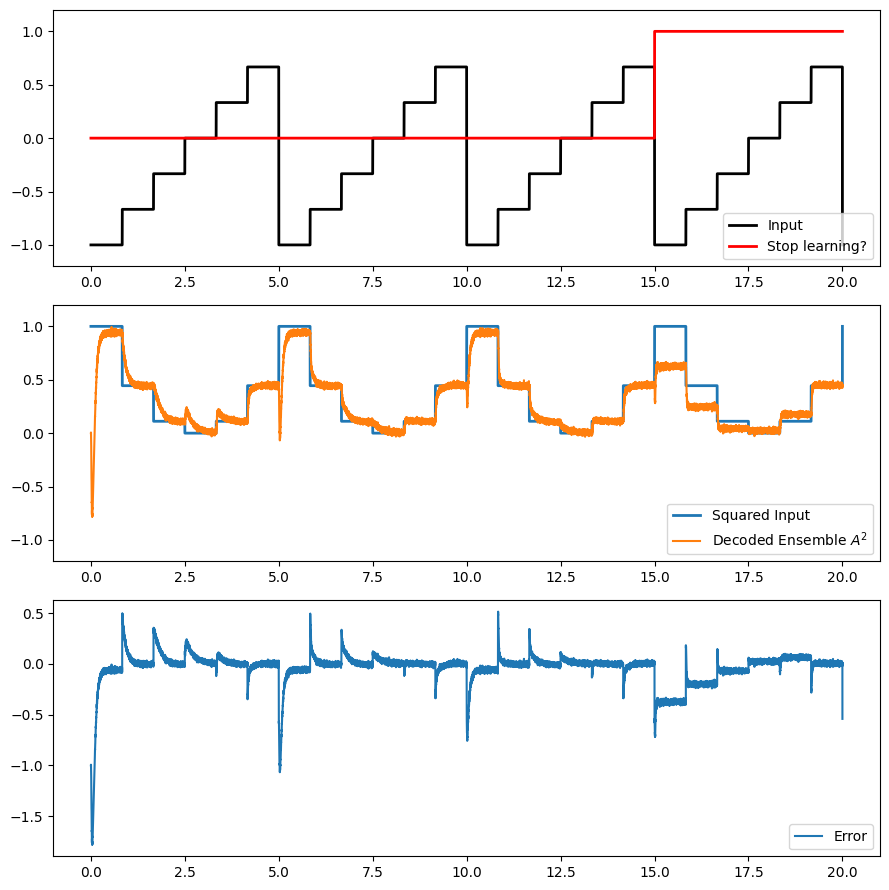

In [8]:
import matplotlib
matplotlib.pyplot.set_loglevel (level = 'warning')

%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 9))
plt.subplot(3, 1, 1)
plt.plot(
    sim.trange(), sim.data[input_node_probe], label="Input", color="k", linewidth=2.0
)
plt.plot(
    sim.trange(),
    sim.data[learn_probe],
    label="Stop learning?",
    color="r",
    linewidth=2.0,
)
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 2)
plt.plot(
    sim.trange(), sim.data[input_node_probe] ** 2, label="Squared Input", linewidth=2.0
)
plt.plot(sim.trange(), sim.data[A_squared_probe], label="Decoded Ensemble $A^2$")
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 3)
plt.plot(
    sim.trange(),
    sim.data[A_squared_probe] - sim.data[input_node_probe] ** 2,
    label="Error",
)
plt.legend(loc="lower right")
plt.tight_layout()

In [13]:
import nengo
nengo.connection.Connection

nengo.connection.Connection